In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
data_dir = "dataset"

print(os.listdir(data_dir))

['daisy', 'dandelion', 'LICENSE.txt', 'roses', 'sunflowers', 'tulips']


In [3]:
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)

    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)))

daisy : 633
dandelion : 898
roses : 641
sunflowers : 699
tulips : 799


In [12]:
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [6]:
class_names = train_ds.class_names

print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


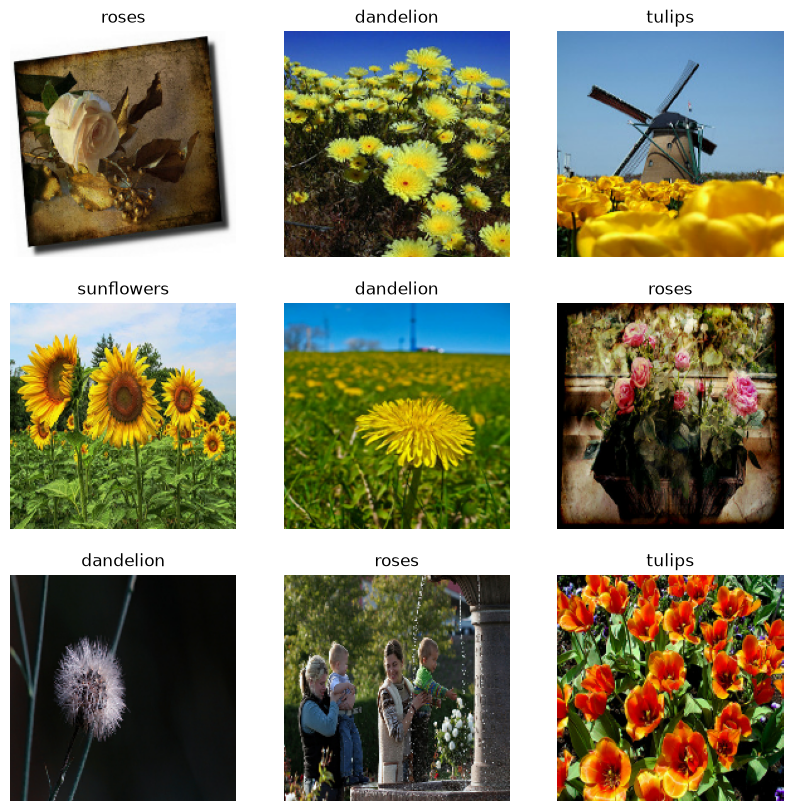

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

for images, labels in train_ds.take(1):
    print("Before:", images[0][0][0])

    normalized_images = normalization_layer(images)

    print("After:", normalized_images[0][0][0])

Before: tf.Tensor([ 88.388885 124.388885 200.38889 ], shape=(3,), dtype=float32)
After: tf.Tensor([0.3466231  0.48779958 0.78583884], shape=(3,), dtype=float32)


In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [12]:
model = tf.keras.Sequential([
    
    data_augmentation,
    
    normalization_layer,
    
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"),
    
    tf.keras.layers.Dense(5, activation="softmax")
])

In [13]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (32, 180, 180, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


c:\Users\PRANJAL\OneDrive\Desktop\flower\.venv-1\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


52/92 ━━━━━━━━━━━━━━━━━━━━ 12s 302ms/step - accuracy: 0.3546 - loss: 1.5167

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

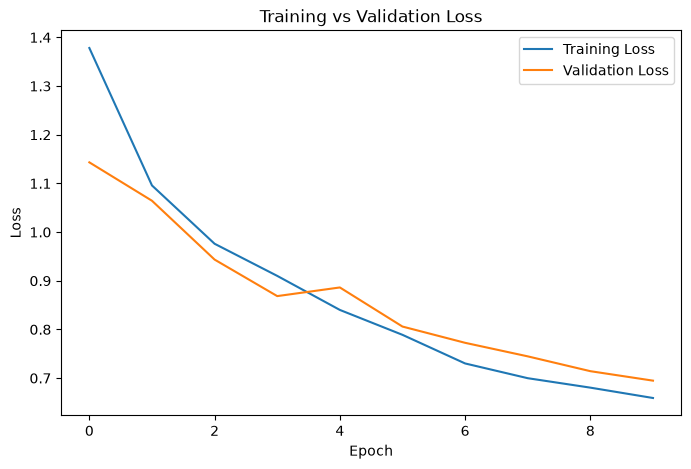

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7234 - loss: 0.6948
Validation Loss: 0.6947624087333679
Validation Accuracy: 0.723433256149292


In [ ]:
model.save("flower_model.keras")

In [ ]:
import os

print(os.path.exists("flower_model.keras"))

True


In [ ]:
import os
import random

class_name = random.choice(class_names)
folder = os.path.join(data_dir, class_name)

image_name = random.choice(os.listdir(folder))
image_path = os.path.join(folder, image_name)

print("Actual class:", class_name)
print("Image path:", image_path)

Actual class: dandelion
Image path: dataset\dandelion\14648777167_1d92d403c9_n.jpg


In [ ]:
img = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)

In [ ]:
img_array = tf.expand_dims(img_array, 0)

In [ ]:
predictions = model.predict(img_array)

score = tf.nn.softmax(predictions[0])

predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted class: dandelion
Confidence: 29.92 %


In [ ]:
class_names[np.argmax(score)]

'dandelion'

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total validation images:", len(y_true))

AttributeError: module 'keras' has no attribute 'KerasTensor'

In [ ]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.15.1


In [16]:
model = tf.keras.models.load_model("flower_model.keras")

In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,942,865 (76.08 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,295,244 (50.72 MB)

In [18]:
data_dir = "dataset"
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [19]:
class_names = val_ds.class_names

print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [20]:
images, labels = next(iter(val_ds))

predictions = model.predict(images, verbose=0)

print(predictions.shape)

(32, 5)


In [21]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total validation images:", len(y_true))


Total validation images: 734


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[ 89  22   8   0  10]
 [ 10 138   3  19   6]
 [  7  12  77   1  23]
 [  9   2   2 134   5]
 [  9  13  32  10  93]]


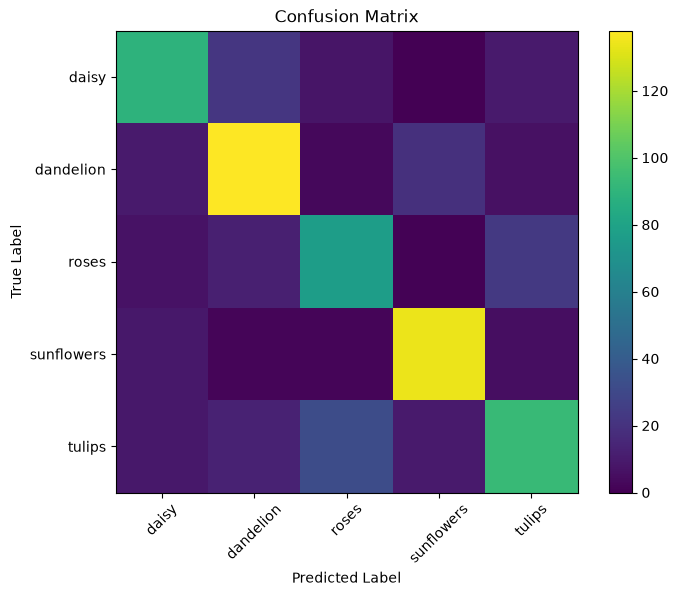

In [23]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

In [24]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

       daisy       0.72      0.69      0.70       129
   dandelion       0.74      0.78      0.76       176
       roses       0.63      0.64      0.64       120
  sunflowers       0.82      0.88      0.85       152
      tulips       0.68      0.59      0.63       157

    accuracy                           0.72       734
   macro avg       0.72      0.72      0.72       734
weighted avg       0.72      0.72      0.72       734



In [25]:
wrong_indices = np.where(y_true != y_pred)[0]

print("Wrong predictions:", len(wrong_indices))

Wrong predictions: 203


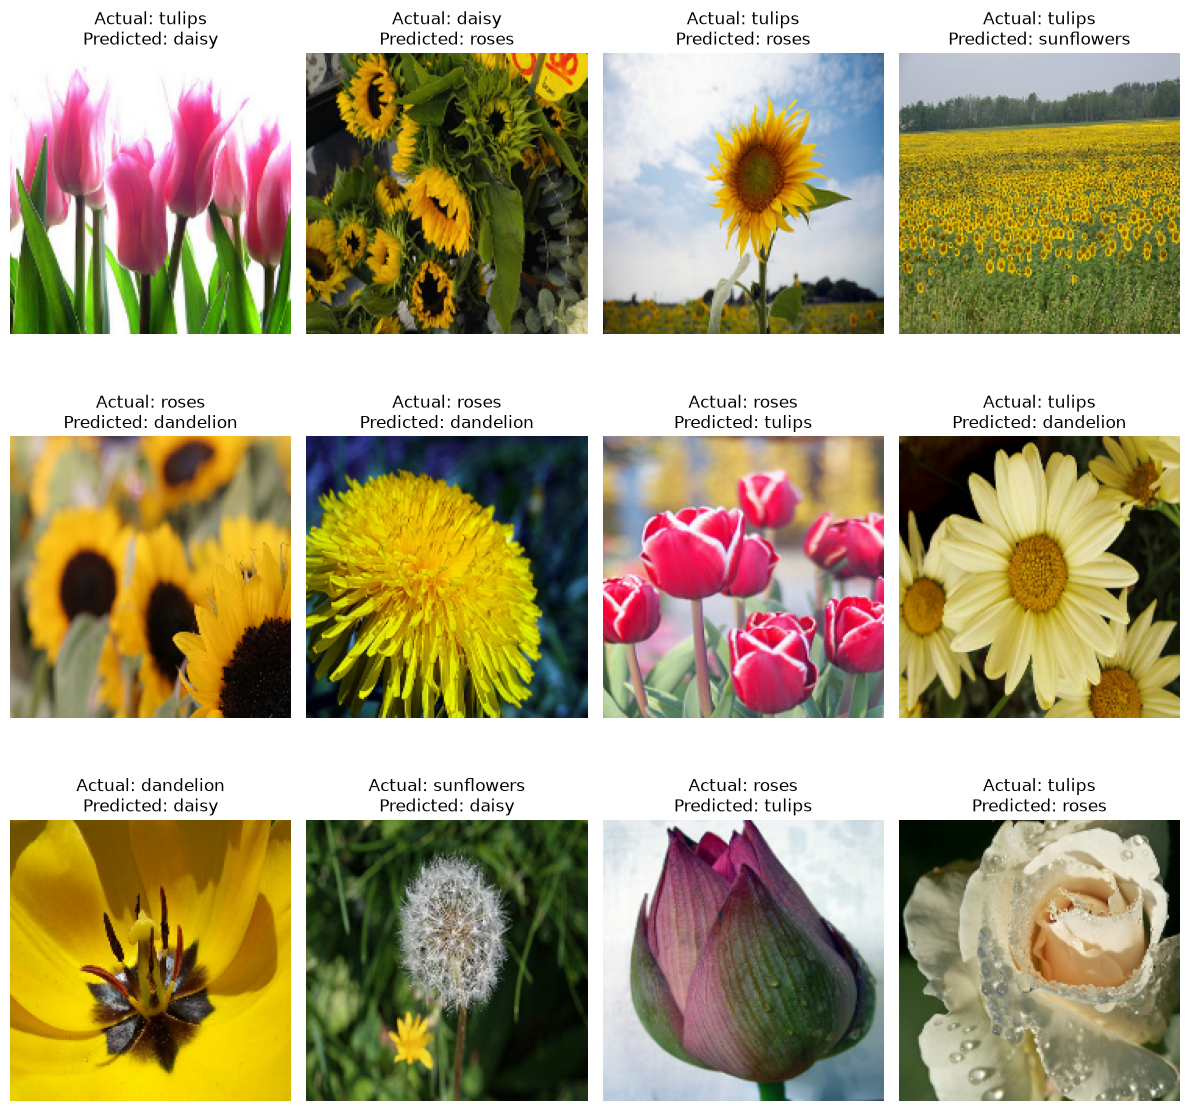

In [26]:
plt.figure(figsize=(12, 12))

for i in range(12):
    index = wrong_indices[i]

    image = None
    true_label = y_true[index]
    predicted_label = y_pred[index]

    # Find the image again from validation dataset
    count = 0

    for images, labels in val_ds:
        batch_size = len(images)

        if index < count + batch_size:
            image = images[index - count]
            break

        count += batch_size

    ax = plt.subplot(3, 4, i + 1)

    plt.imshow(image.numpy().astype("uint8"))

    plt.title(
        f"Actual: {class_names[true_label]}\n"
        f"Predicted: {class_names[predicted_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
from collections import Counter

mistakes = Counter()

for true, pred in zip(y_true, y_pred):
    if true != pred:
        mistakes[(class_names[true], class_names[pred])] += 1

for (actual, predicted), count in mistakes.most_common():
    print(f"{actual} → {predicted}: {count}")

tulips → roses: 32
roses → tulips: 23
daisy → dandelion: 22
dandelion → sunflowers: 19
tulips → dandelion: 13
roses → dandelion: 12
tulips → sunflowers: 10
dandelion → daisy: 10
daisy → tulips: 10
tulips → daisy: 9
sunflowers → daisy: 9
daisy → roses: 8
roses → daisy: 7
dandelion → tulips: 6
sunflowers → tulips: 5
dandelion → roses: 3
sunflowers → roses: 2
sunflowers → dandelion: 2
roses → sunflowers: 1


In [11]:
def predict_flower(image):
    img = image.resize(IMG_SIZE)

    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)
    score = predictions[0]

    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    return predicted_class, confidence

In [15]:
from PIL import Image
import os
import matplotlib.pyplot as plt
import tensorflow as tf


In [5]:
os.listdir("dataset/roses")[:5]

['10090824183_d02c613f10_m.jpg',
 '102501987_3cdb8e5394_n.jpg',
 '10503217854_e66a804309.jpg',
 '10894627425_ec76bbc757_n.jpg',
 '110472418_87b6a3aa98_m.jpg']

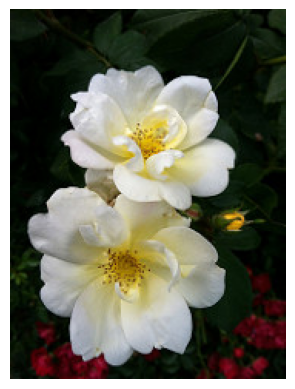

In [9]:
from PIL import Image
import os

image_path = "dataset/roses/10090824183_d02c613f10_m.jpg"

image = Image.open(image_path)

plt.imshow(image)
plt.axis("off")
plt.show()

In [16]:
predicted_class, confidence = predict_flower(image)

print("Predicted flower:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

NameError: name 'model' is not defined

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

In [18]:
model = tf.keras.models.load_model("flower_model.keras")

In [19]:
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [20]:
def predict_flower(image):
    img = image.resize(IMG_SIZE)

    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)
    score = predictions[0]

    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    return predicted_class, confidence

In [21]:
os.listdir("dataset/roses")[:5]

['10090824183_d02c613f10_m.jpg',
 '102501987_3cdb8e5394_n.jpg',
 '10503217854_e66a804309.jpg',
 '10894627425_ec76bbc757_n.jpg',
 '110472418_87b6a3aa98_m.jpg']

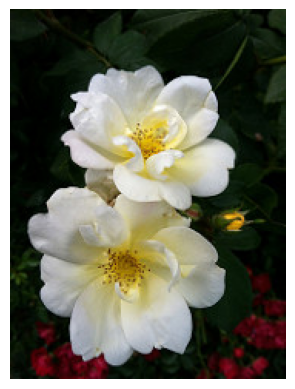

In [22]:
image_path = "dataset/roses/" + os.listdir("dataset/roses")[0]

image = Image.open(image_path)

plt.imshow(image)
plt.axis("off")
plt.show()

In [23]:
predicted_class, confidence = predict_flower(image)

print("Predicted flower:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

Predicted flower: roses
Confidence: 84.27 %


## DAY 5

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

C:\Users\PRANJAL\AppData\Local\Temp\ipykernel_6952\3748499592.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


In [4]:
model_tl = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(5, activation="softmax")
])

In [5]:
model_tl.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:
model_tl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
import tensorflow as tf

data_dir = "dataset"
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print(class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [9]:
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


c:\Users\PRANJAL\OneDrive\Desktop\flower\.venv-1\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 515ms/step - accuracy: 0.3992 - loss: 1.4911 - val_accuracy: 0.4796 - val_loss: 1.2822
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 360ms/step - accuracy: 0.5296 - loss: 1.2016 - val_accuracy: 0.5436 - val_loss: 1.1431
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.5974 - loss: 1.0590 - val_accuracy: 0.5681 - val_loss: 1.0912
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - accuracy: 0.6168 - loss: 1.0023 - val_accuracy: 0.5749 - val_loss: 1.0509
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 221ms/step - accuracy: 0.6390 - loss: 0.9392 - val_accuracy: 0.6185 - val_loss: 1.0184
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.6625 - loss: 0.8846 - val_accuracy: 0.5872 - val_loss: 1.0809
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.6873 - loss: 0.8370 - val_accuracy: 0.5981 - val_loss: 1.0122
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 218ms/step - accuracy: 0.7027 - loss: 0.7861 - val_accuracy: 0.613

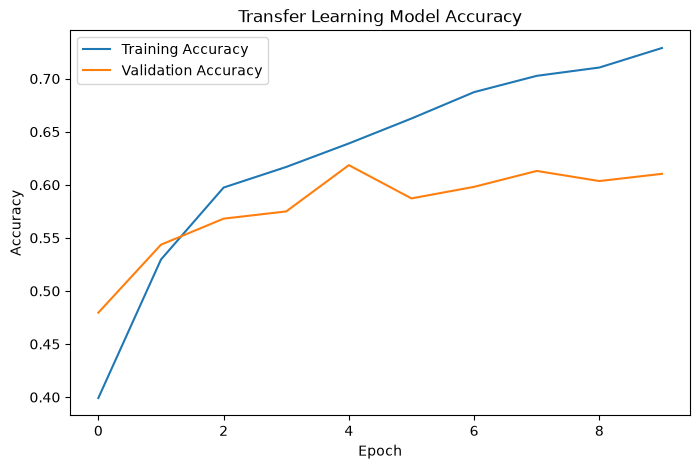

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history_tl.history["accuracy"], label="Training Accuracy")
plt.plot(history_tl.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Model Accuracy")
plt.legend()

plt.show()

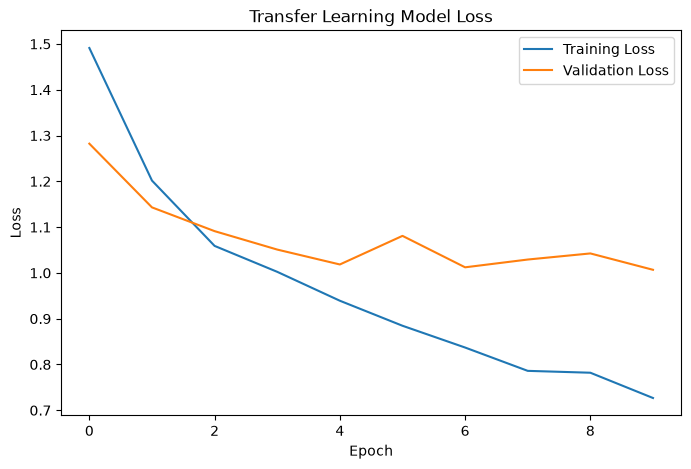

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history_tl.history["loss"], label="Training Loss")
plt.plot(history_tl.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Model Loss")
plt.legend()

plt.show()

In [12]:
loss_tl, accuracy_tl = model_tl.evaluate(val_ds)

print("Transfer Learning Validation Loss:", loss_tl)
print("Transfer Learning Validation Accuracy:", accuracy_tl)

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.6104 - loss: 1.0068
Transfer Learning Validation Loss: 1.006780982017517
Transfer Learning Validation Accuracy: 0.6103542447090149


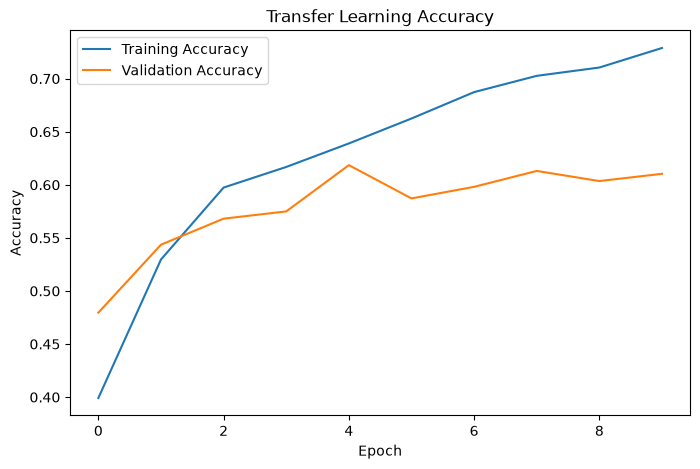

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history_tl.history["accuracy"], label="Training Accuracy")
plt.plot(history_tl.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy")
plt.legend()

plt.show()

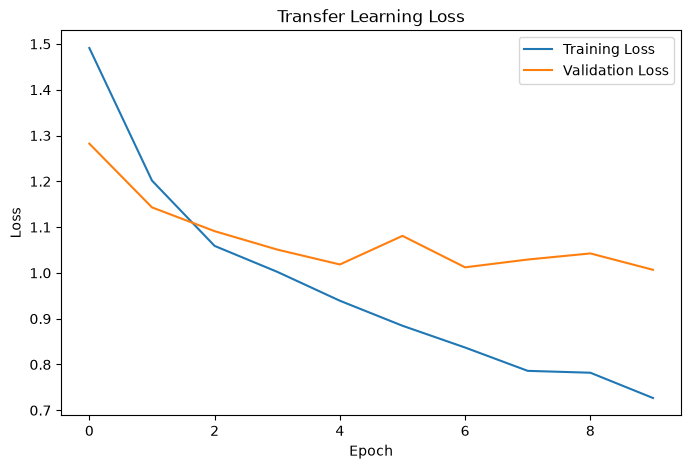

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history_tl.history["loss"], label="Training Loss")
plt.plot(history_tl.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss")
plt.legend()

plt.show()

## transfer leranring failed , so we are doing it again

In [15]:
data_augmentation_tl = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [16]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model_tl = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(180, 180, 3)),
    data_augmentation_tl,
    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(5, activation="softmax")
])

C:\Users\PRANJAL\AppData\Local\Temp\ipykernel_6952\1811356425.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [17]:
model_tl.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 415ms/step - accuracy: 0.7285 - loss: 0.7180 - val_accuracy: 0.8665 - val_loss: 0.4037
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 76s 792ms/step - accuracy: 0.8409 - loss: 0.4333 - val_accuracy: 0.8774 - val_loss: 0.3520
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.8678 - loss: 0.3565 - val_accuracy: 0.8856 - val_loss: 0.3329
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 235ms/step - accuracy: 0.8787 - loss: 0.3169 - val_accuracy: 0.8910 - val_loss: 0.3342
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 234ms/step - accuracy: 0.8968 - loss: 0.2930 - val_accuracy: 0.8937 - val_loss: 0.3216
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 232ms/step - accuracy: 0.9067 - loss: 0.2620 - val_accuracy: 0.8924 - val_loss: 0.3067
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 234ms/step - accuracy: 0.9019 - loss: 0.2451 - val_accuracy: 0.8951 - val_loss: 0.3019
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 299ms/step - accuracy: 0.9043 - loss: 0.2426 - val_accu

In [19]:
loss_tl, accuracy_tl = model_tl.evaluate(val_ds)

print("Transfer Learning Validation Loss:", loss_tl)
print("Transfer Learning Validation Accuracy:", accuracy_tl)

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.9060 - loss: 0.3128
Transfer Learning Validation Loss: 0.31282839179039
Transfer Learning Validation Accuracy: 0.9059945344924927


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [21]:
y_true_tl = []
y_pred_tl = []

for images, labels in val_ds:
    predictions = model_tl.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(predicted_labels)

y_true_tl = np.array(y_true_tl)
y_pred_tl = np.array(y_pred_tl)

In [22]:
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

print(cm_tl)

[[117   1   5   2   4]
 [  1 166   1   6   2]
 [  2   2 101   4  11]
 [  4   5   2 141   0]
 [  2   2   8   5 140]]


In [23]:
print(classification_report(
    y_true_tl,
    y_pred_tl,
    target_names=class_names
))

              precision    recall  f1-score   support

       daisy       0.93      0.91      0.92       129
   dandelion       0.94      0.94      0.94       176
       roses       0.86      0.84      0.85       120
  sunflowers       0.89      0.93      0.91       152
      tulips       0.89      0.89      0.89       157

    accuracy                           0.91       734
   macro avg       0.90      0.90      0.90       734
weighted avg       0.91      0.91      0.91       734



In [24]:
model_tl.save("flower_model_tl.keras")

In [25]:
import os

print(os.path.exists("flower_model_tl.keras"))

True


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)
print(tf.keras.__version__)

2.21.0
3.15.1


In [2]:
model = tf.keras.models.load_model(
    "flower_model.keras",
    compile=False
)

In [3]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,621 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import tensorflow as tf
import numpy as np

data_dir = "dataset"
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = val_ds.class_names

print(class_names)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [6]:
images, labels = next(iter(val_ds))

predictions = model.predict(images, verbose=0)

print(predictions.shape)

(32, 5)


In [7]:
for i in range(5):
    predicted_index = np.argmax(predictions[i])
    predicted_class = class_names[predicted_index]
    confidence = predictions[i][predicted_index] * 100

    print(
        f"Image {i+1}: {predicted_class} "
        f"({confidence:.2f}%)"
    )

Image 1: dandelion (91.48%)
Image 2: dandelion (46.20%)
Image 3: sunflowers (99.62%)
Image 4: roses (58.84%)
Image 5: tulips (90.12%)
